In [1]:
# Plot ensemble mean and each ensemble member for OSDMA8

In [2]:
import os
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import cartopy.feature as cfeature
import cartopy.crs as ccrs
from utils.utils import autosize_figure, land_filter

In [4]:
# === Path config ===
MORT_DIR = "/glade/work/awells/air_quality/CESM/mortality/ozone/"

# === Main loop ===
ssp245_file = "Mortality_Country_sum_CESM2_SSP245_2020-2068.nc"
ssp245_path = os.path.join(MORT_DIR, ssp245_file)
ssp245 = xr.open_dataarray(ssp245_path)

arise_file = "Mortality_Country_sum_CESM2_ARISE_2035-2068.nc"
arise_path = os.path.join(MORT_DIR, arise_file)
arise = xr.open_dataarray(arise_path)

In [5]:
ssp245 = ssp245.sel(year=slice("2060", "2068")).mean("year")

In [7]:
difference = (arise - ssp245).sel(year=slice("2060", "2068")).mean("year")

In [8]:
def create_global_country_map(da):
    # Path config
    MASKS_DIR = "/glade/work/awells/air_quality/BMR/masks/country/"

    # Load in country mask
    mask_file = "GBD_Country_Masks_0.10.nc"
    mask_path = os.path.join(MASKS_DIR, mask_file)
    masks = xr.open_dataarray(mask_path)

    # Create DataArray filled with NaNs
    global_array = xr.DataArray(
        np.full((len(masks.lat), len(masks.lon), len(da.ensemble)), np.nan),
        coords={"lat": masks.lat.values, "lon": masks.lon.values, "ensemble": da.ensemble.values},
        dims=["lat", "lon", "ensemble"]
    )

    # Loop over countries, select the data for each country and apply to
    # empty array using the country mask
    for i in range(len(masks.country)):
        mask = masks.isel(country=i)
        country = masks.isel(country=i)["country"]
        mortality_country = da.sel(country=country)
        global_array = global_array.where(mask == 0, mortality_country)

    return global_array

In [9]:
global_difference = create_global_country_map(difference)
global_ssp245 = create_global_country_map(ssp245)

In [10]:
diff_mean = global_difference.mean("ensemble")
ssp245_mean = global_ssp245.mean("ensemble")

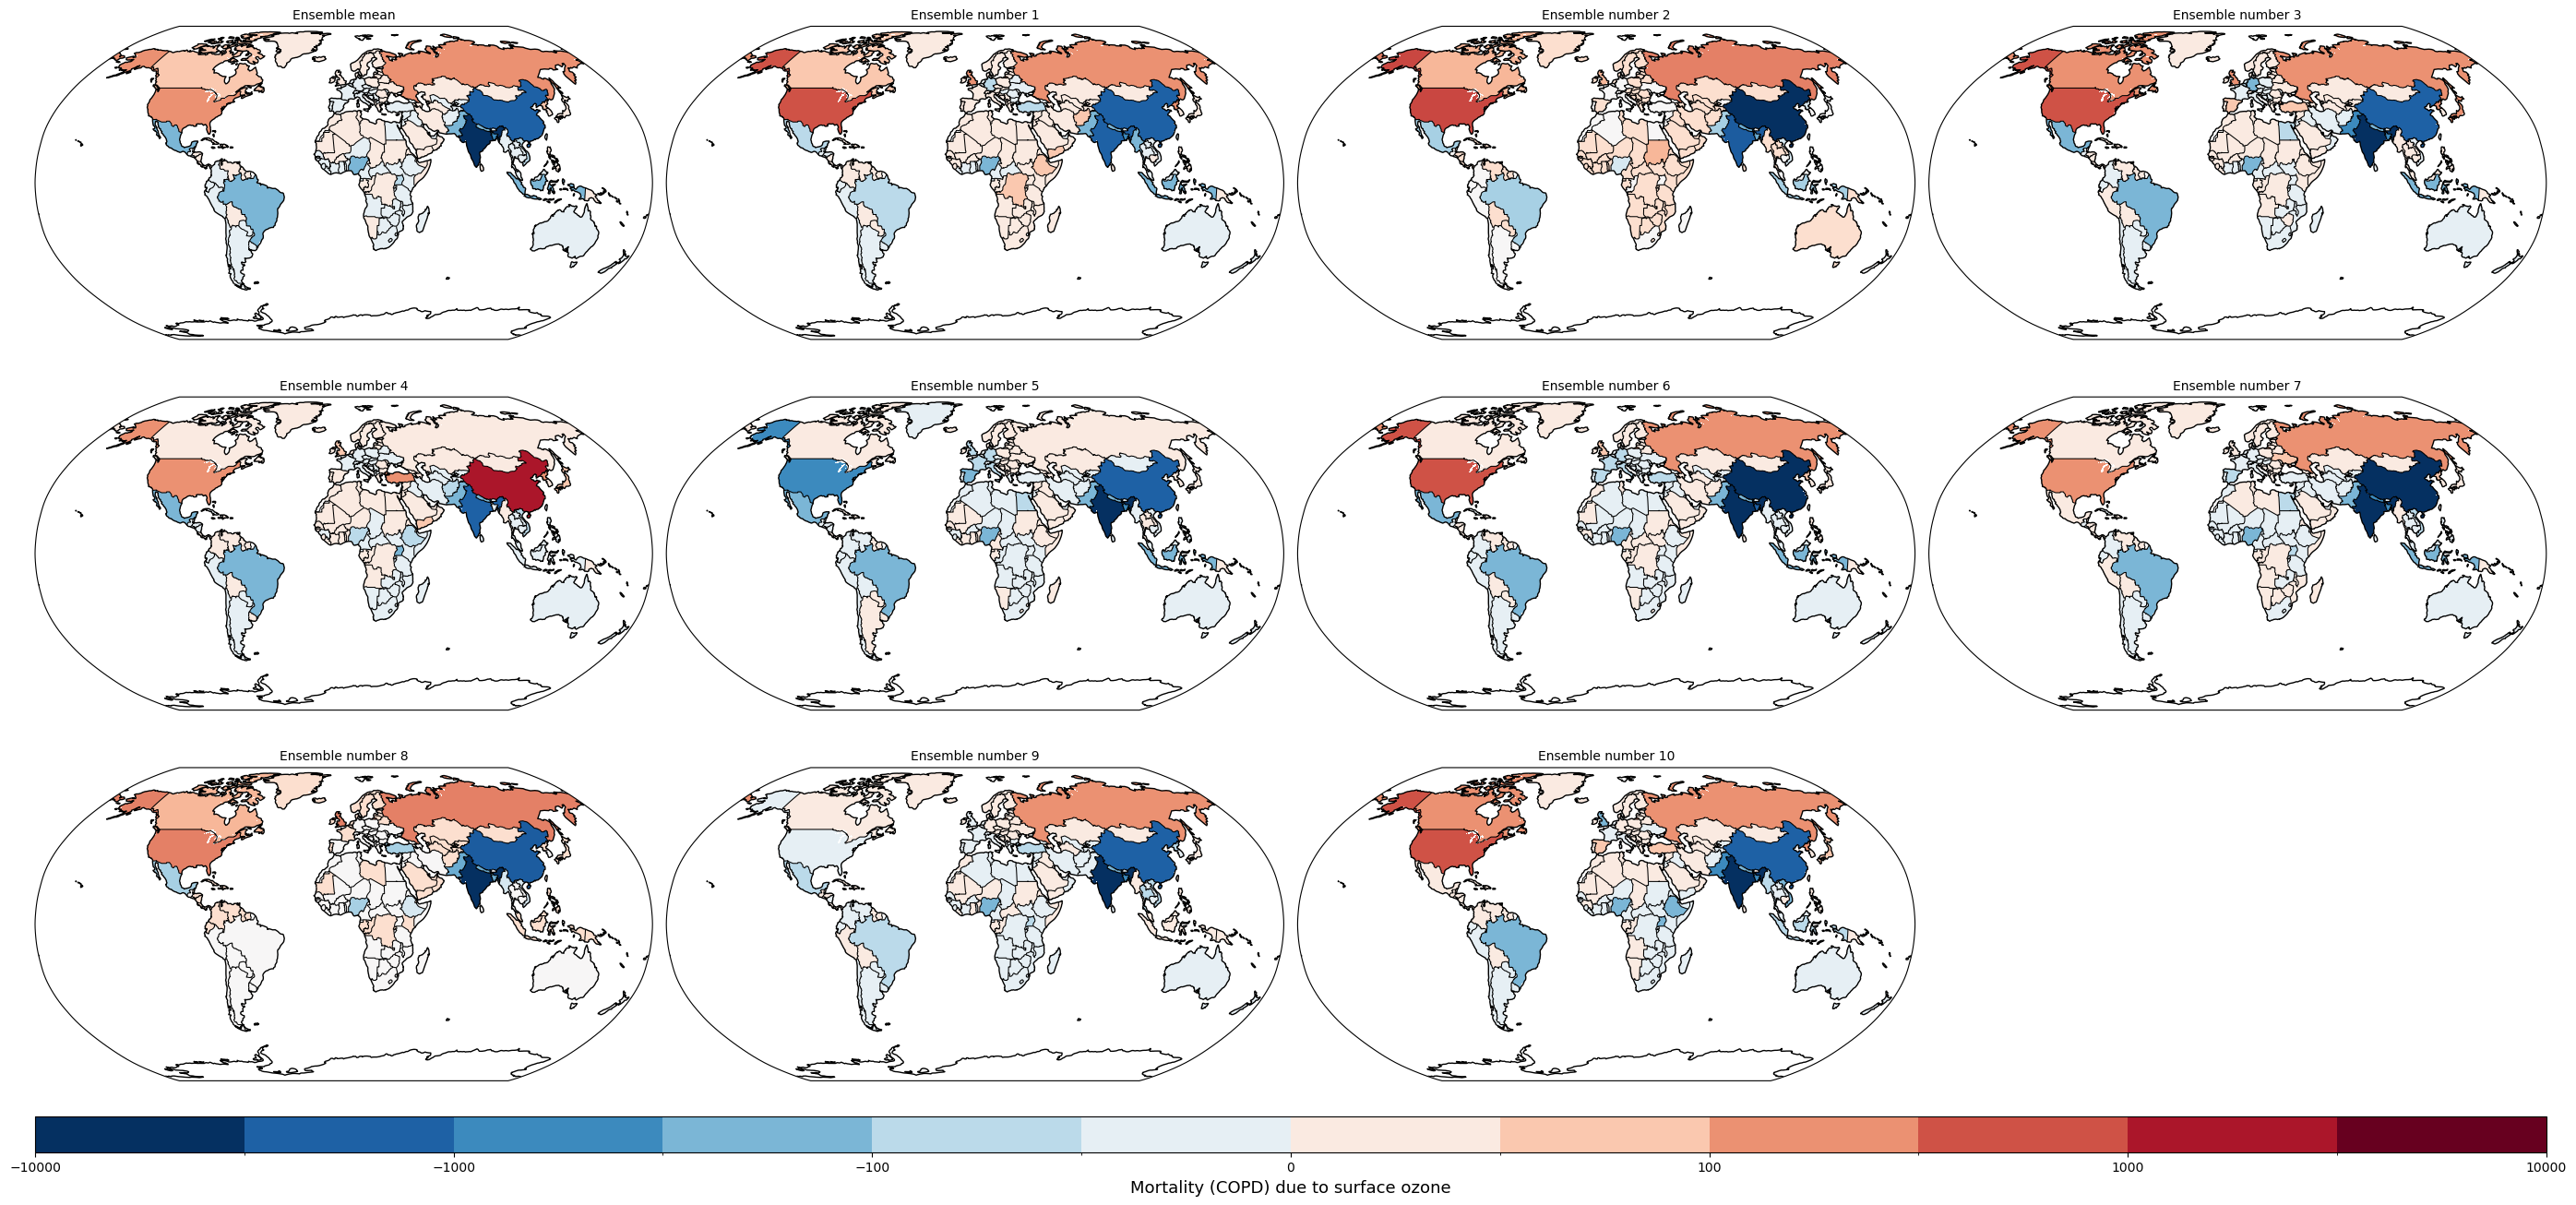

In [20]:
# Create figure
fig = plt.figure(figsize=autosize_figure(3, 4, xscale_factor=1.2))
gs = GridSpec(4, 4, height_ratios=[10, 10, 10, 1])  # rows, columns

projection = ccrs.Robinson()
crs = ccrs.PlateCarree()

cmap = "RdBu_r"
levels = [-10000, -5000, -1000, -500, -100, -50, 0, 50, 100, 500, 1000, 5000, 10000]

country_borders = cfeature.NaturalEarthFeature(
    category='cultural',
    name='admin_0_boundary_lines_land',
    scale='50m',
    facecolor='none')

# First panel - ensemble mean
ax = fig.add_subplot(gs[0, 0], projection=projection, frameon=True)
cb = land_filter(diff_mean).plot(
    transform=crs,
    cmap=cmap,
    levels=levels,
    add_colorbar=False,
    subplot_kws={'projection': projection}
)
ax.coastlines()
ax.add_feature(country_borders, edgecolor='k', linewidth=0.75)
plt.title("Ensemble mean", fontsize=10)

rows = 4
cols = 4
start_index = 1 * cols  # start from row 1 (second row)
for i in range(1, 11):
    da = global_difference.sel(ensemble=i)

    grid_index = i  # i starts at 1, so grid_index also starts at 1
    row = grid_index // cols
    col = grid_index % cols
    ax = fig.add_subplot(gs[row, col], projection=projection, frameon=True)
    cb = land_filter(da).plot(
        transform=crs,
        cmap=cmap,
        levels=levels,
        add_colorbar=False,
        subplot_kws={'projection': projection}
    )
    ax.coastlines()
    ax.add_feature(country_borders, edgecolor='k', linewidth=0.75)
    plt.title(f"Ensemble number {i}", fontsize=10)

cax = fig.add_subplot(gs[3, :])
col_bar = plt.colorbar(cb, cax=cax, orientation='horizontal')
col_bar.set_label("Mortality (COPD) due to surface ozone", fontsize=13)

plt.tight_layout()

In [ ]:
# Create figure
fig = plt.figure(figsize=autosize_figure(3, 4, xscale_factor=1.2))
gs = GridSpec(4, 4, height_ratios=[10, 10, 10, 1])  # rows, columns

projection = ccrs.Robinson()
crs = ccrs.PlateCarree()

cmap = "Reds"
levels = [0, 1000, 2500, 5000, 7500, 10000, 25000, 50000, 75000, 100000, 250000]

country_borders = cfeature.NaturalEarthFeature(
    category='cultural',
    name='admin_0_boundary_lines_land',
    scale='50m',
    facecolor='none')

# First panel - ensemble mean
ax = fig.add_subplot(gs[0, 0], projection=projection, frameon=True)
cb = land_filter(ssp245_mean).plot(
    transform=crs,
    cmap=cmap,
    levels=levels,
    add_colorbar=False,
    subplot_kws={'projection': projection}
)
ax.coastlines()
ax.add_feature(country_borders, edgecolor='k', linewidth=0.75)
plt.title("Ensemble mean", fontsize=10)

rows = 4
cols = 4
start_index = 1 * cols  # start from row 1 (second row)
for i in range(1, 11):
    da = global_ssp245.sel(ensemble=i)

    grid_index = i  # i starts at 1, so grid_index also starts at 1
    row = grid_index // cols
    col = grid_index % cols
    ax = fig.add_subplot(gs[row, col], projection=projection, frameon=True)
    cb = land_filter(da).plot(
        transform=crs,
        cmap=cmap,
        levels=levels,
        add_colorbar=False,
        subplot_kws={'projection': projection}
    )
    ax.coastlines()
    ax.add_feature(country_borders, edgecolor='k', linewidth=0.75)
    plt.title(f"Ensemble number {i}", fontsize=10)

cax = fig.add_subplot(gs[3, :])
col_bar = plt.colorbar(cb, cax=cax, orientation='horizontal')
col_bar.set_label("Mortality (COPD) due to surface ozone", fontsize=13)

plt.tight_layout()